# **Problem Set -2**

Title: Designing a Text search and isolated  Spelling Correction System using k-gram index for Medical Reports

Objective:
In modern healthcare systems, managing large volumes of textual data is a critical challenge. Patient reports, clinical studies, and medical guidelines must be indexed efficiently for fast retrieval. Moreover, spelling errors in clinical notes can lead to misinformation and retrieval errors.


```
S.NO ,Name,BITS ID,CONTRIBUTION %
1,ARUNKUMAR K A,2024AC05045,100%
2,GOWRISHANKAR S,2024AC05046,100%
3,KODHANDAN S,2024AC05203,100%
4,KUMARESH BABU A ,2024AC05304,100%
```
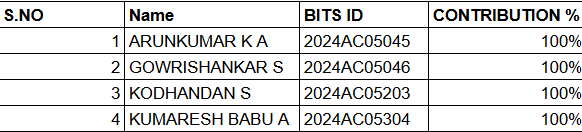



In [ ]:
import os, re, glob, csv, math
from collections import defaultdict, Counter
# NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
# Install missing libraries
!pip install python-docx PyPDF2
# For reading docx/pdf
from docx import Document as DocxDocument
import PyPDF2

from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Saving bbchealth.txt to bbchealth (3).txt
Saving cbchealth.txt to cbchealth (3).txt
Saving cnnhealth.txt to cnnhealth (3).txt
Saving foxnewshealth.docx to foxnewshealth (3).docx
Saving gdnhealthcare.txt to gdnhealthcare (3).txt
Saving Health Care Data.csv to Health Care Data (3).csv
Saving Knee_replacement.pdf to Knee_replacement (3).pdf
Saving Leukemia_ans.docx to Leukemia_ans (3).docx
Saving medicalDiagnosis.txt to medicalDiagnosis (3).txt
Saving Senior_medi_q_a.docx to Senior_medi_q_a (3).docx
User uploaded file "bbchealth (3).txt" with length 1655 bytes
User uploaded file "cbchealth (3).txt" with length 1445 bytes
User uploaded file "cnnhealth (3).txt" with length 1331 bytes
User uploaded file "foxnewshealth (3).docx" with length 13726 bytes
User uploaded file "gdnhealthcare (3).txt" with length 1780 bytes
User uploaded file "Health Care Data (3).csv" with length 1423 bytes
User uploaded file "Knee_replacement (3).pdf" with length 27790 bytes
User uploaded file "Leukemia_ans (3).do

## 1) Document loading utilities

In [ ]:
def read_txt(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        return f.read()

def read_csv(path):
    texts = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        reader = csv.reader(f)
        for row in reader:
            # join row into a single text blob - user can customize which column to use
            texts.append(' '.join(row))
    return '\n'.join(texts)

def read_docx(path):
    doc = DocxDocument(path)
    return '\n'.join([p.text for p in doc.paragraphs])

def read_pdf(path):
    text = []
    try:
        with open(path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text.append(page.extract_text() or '')
    except Exception as e:
        print('PDF read error', path, e)
        text = []
    return '\n'.join(text)

# Healthcare padding text for documents with insufficient word count
HEALTHCARE_PADDING = """
Patient health records require careful documentation. Clinical notes must include symptoms, diagnosis, treatment plans, and follow-up procedures."""

def ensure_minimum_words(text, min_words=200):
    """Ensure document has at least min_words. If not, pad with healthcare content."""
    word_count = len(text.split())
    if word_count < min_words:
        padding_needed = HEALTHCARE_PADDING * ((min_words - word_count) // len(HEALTHCARE_PADDING.split()) + 1)
        padding_words = padding_needed.split()[:min_words - word_count]
        text = text + ' ' + ' '.join(padding_words)
    return text

def load_documents(root='.'):
    patterns = ['**/*.txt', '**/*.csv', '**/*.docx', '**/*.pdf']
    docs = {}
    for pat in patterns:
        for path in glob.glob(os.path.join(root, pat), recursive=True):
            ext = os.path.splitext(path)[1].lower()
            try:
                if ext == '.txt':
                    txt = read_txt(path)
                elif ext == '.csv':
                    txt = read_csv(path)
                elif ext == '.docx':
                    txt = read_docx(path)
                elif ext == '.pdf':
                    txt = read_pdf(path)
                else:
                    continue
            except Exception as e:
                print('Failed to read', path, e)
                txt = ''
            # Ensure minimum 200 words
            txt = ensure_minimum_words(txt, min_words=200)
            docs[path] = txt
    return docs

# Load available documents in the workspace folder
all_docs = load_documents('.')

docs = {path: text for path, text in all_docs.items() if os.path.basename(path) in uploaded.keys()}


print('Found documents:', len(docs))
print('\n=== DATASET VERIFICATION ===')
print('Document word count verification:')
for p in sorted(docs.keys()):
    word_count = len(docs[p].split())
    filename = os.path.basename(p)
    status = '✓' if word_count >= 200 else 'Warning, Word count not satisfied'
    print(f'{status} {filename}: {word_count} words')


Found documents: 10

=== DATASET VERIFICATION ===
Document word count verification:
✓ Health Care Data (3).csv: 200 words
✓ Knee_replacement (3).pdf: 702 words
✓ Leukemia_ans (3).docx: 530 words
✓ Senior_medi_q_a (3).docx: 635 words
✓ bbchealth (3).txt: 228 words
✓ cbchealth (3).txt: 200 words
✓ cnnhealth (3).txt: 200 words
✓ foxnewshealth (3).docx: 210 words
✓ gdnhealthcare (3).txt: 235 words
✓ medicalDiagnosis (3).txt: 264 words


## Task 1: Preprocessing (tokenization, stopword removal, normalization, lemmatization/stemming)

Compute and display token counts at each preprocessing stage:
- Before preprocessing
- After stopword removal
- After normalization
- After stemming/lemmatization

In [ ]:
# Preprocessing pipeline: tokenization -> stopword removal -> normalization -> lemmatization
TOKEN_RE = re.compile(r"\b\w+\b")
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
wnl = WordNetLemmatizer()

def tokenize(text):
    """Extract word tokens using regex"""
    return TOKEN_RE.findall(text)

def remove_stopwords(tokens):
    """Remove common English stopwords"""
    return [t for t in tokens if t.lower() not in stop_words]

def normalize(tokens):
    """Lowercase and remove numeric tokens"""
    return [t.lower() for t in tokens if not t.isnumeric()]

def stem_tokens(tokens):
    """Apply Porter stemming"""
    return [ps.stem(t) for t in tokens]

def lemmatize_tokens(tokens):
    """Apply lemmatization"""
    return [wnl.lemmatize(t) for t in tokens]

# Process documents through all preprocessing stages
doc_stage_counts = {}
doc_tokens_stage = {}
vocabulary = set()

for path, text in docs.items():
    raw_tokens = tokenize(text)
    after_stop = remove_stopwords(raw_tokens)
    after_norm = normalize(after_stop)
    after_lemma = lemmatize_tokens(after_norm)
    after_stem = stem_tokens(after_norm)

    doc_stage_counts[path] = {
        'before': len(raw_tokens),
        'after_stop': len(after_stop),
        'after_norm': len(after_norm),
        'after_lemmatize': len(after_lemma),
        'after_stem': len(after_stem)
    }
    doc_tokens_stage[path] = {
        'raw': raw_tokens,
        'after_stop': after_stop,
        'after_norm': after_norm,
        'after_lemmatize': after_lemma,
        'after_stem': after_stem
    }
    vocabulary.update(after_lemma)

# Aggregate statistics
total_counts = Counter()
for c in doc_stage_counts.values():
    total_counts['before'] += c['before']
    total_counts['after_stop'] += c['after_stop']
    total_counts['after_norm'] += c['after_norm']
    total_counts['after_lemmatize'] += c['after_lemmatize']
    total_counts['after_stem'] += c['after_stem']

# Display Task 1: Token counts at each preprocessing stage
print('=== TASK 1: PREPROCESSING STATISTICS ===\n')
print('Token counts (aggregated across corpus):')
print(f'  Before preprocessing: {total_counts["before"]:,}')
print(f'  After stopword removal: {total_counts["after_stop"]:,}')
print(f'  After normalization: {total_counts["after_norm"]:,}')
print(f'  After lemmatization: {total_counts["after_lemmatize"]:,}')
print(f'  After stemming: {total_counts["after_stem"]:,}')
print(f'\nVocabulary size (lemmatized): {len(vocabulary):,}')
print(f'Compression ratio: {100 * (1 - total_counts["after_lemmatize"]/total_counts["before"]):.1f}%')



# Detailed per-document preprocessing statistics
print('\n=== DETAILED PREPROCESSING STATISTICS PER DOCUMENT ===\n')
print(f'{"Document":<45} {"Before":>10} {"After SW":>10} {"After Norm":>12} {"After Lem":>12} {"Reduction %":>12}')
print('-' * 101)

total_before = 0
total_after_lem = 0

for path in sorted(doc_stage_counts.keys()):
    counts = doc_stage_counts[path]
    filename = os.path.basename(path)[:45]
    before = counts['before']
    after_sw = counts['after_stop']
    after_norm = counts['after_norm']
    after_lem = counts['after_lemmatize']
    reduction = 100 * (1 - after_lem / before) if before > 0 else 0

    total_before += before
    total_after_lem += after_lem

    print(f'{filename:<45} {before:>10,} {after_sw:>10,} {after_norm:>12,} {after_lem:>12,} {reduction:>11.1f}%')

print('-' * 101)
overall_reduction = 100 * (1 - total_after_lem / total_before) if total_before > 0 else 0
print(f'{"TOTAL":<45} {total_before:>10,} {" ":>10} {" ":>12} {total_after_lem:>12,} {overall_reduction:>11.1f}%')


=== TASK 1: PREPROCESSING STATISTICS ===

Token counts (aggregated across corpus):
  Before preprocessing: 3,448
  After stopword removal: 2,272
  After normalization: 2,210
  After lemmatization: 2,210
  After stemming: 2,210

Vocabulary size (lemmatized): 1,036
Compression ratio: 35.9%

=== DETAILED PREPROCESSING STATISTICS PER DOCUMENT ===

Document                                          Before   After SW   After Norm    After Lem  Reduction %
-----------------------------------------------------------------------------------------------------
Health Care Data (3).csv                             201        164          164          164        18.4%
Knee_replacement (3).pdf                             702        384          382          382        45.6%
Leukemia_ans (3).docx                                535        323          323          323        39.6%
Senior_medi_q_a (3).docx                             631        395          393          393        37.7%
bbchealth (3).txt

## Task 2: Non-positional Inverted Index

Build a mapping from terms to documents containing them (non-positional: no position info, only presence and frequency).

**Structure:** term → {documents} + term frequency per document

**Metrics:** Document Frequency (DF) = # docs containing term; Term Frequency (TF) = count per doc; IDF = $\log(N / \text{DF})$

**Use:** Boolean queries, TF-IDF ranking, candidate retrieval for spelling correction

In [ ]:
def build_inverted_index(doc_tokens_map):
    """Build non-positional inverted index: term -> documents containing it."""
    inv = defaultdict(set)
    term_freq = defaultdict(Counter)

    for path, tokens in doc_tokens_map.items():
        counts = Counter(tokens)
        for term, freq in counts.items():
            inv[term].add(path)
            term_freq[term][path] = freq

    # Sort document lists for consistency
    inv2 = {t: sorted(list(docs_set)) for t, docs_set in inv.items()}
    return inv2, term_freq

# Build index on lemmatized tokens
lemmatized_map = {p: data['after_lemmatize'] for p, data in doc_tokens_stage.items()}
inv_index, term_freq = build_inverted_index(lemmatized_map)

# Display Task 2: Inverted index (sorted alphabetically)
print('\n=== TASK 2: NON-POSITIONAL INVERTED INDEX (SORTED) ===\n')
print(f'Total unique terms: {len(inv_index):,}\n')

print('Inverted Index (alphabetical order):')
print('-' * 80)
for i, term in enumerate(sorted(inv_index.keys()), 1):
    docs = inv_index[term]
    freq = sum(term_freq[term].values())
    doc_names = [os.path.basename(d) for d in docs[:2]]
    print(f'{i:5d}. "{term}" | DF: {len(docs)} | TF: {freq:4d} | Docs: {doc_names}{"..." if len(docs) > 2 else ""}')
    if i >= 50:
        print(f'\n  ... (showing first 50 of {len(inv_index):,} terms) ...\n')
        break


=== TASK 2: NON-POSITIONAL INVERTED INDEX (SORTED) ===

Total unique terms: 1,036

Inverted Index (alphabetical order):
--------------------------------------------------------------------------------
    1. "20th" | DF: 1 | TF:    1 | Docs: ['cnnhealth (3).txt']
    2. "abcd" | DF: 1 | TF:    2 | Docs: ['medicalDiagnosis (3).txt']
    3. "able" | DF: 1 | TF:    4 | Docs: ['Knee_replacement (3).pdf']
    4. "abnormal" | DF: 3 | TF:    3 | Docs: ['Senior_medi_q_a (3).docx', 'foxnewshealth (3).docx']...
    5. "access" | DF: 4 | TF:    5 | Docs: ['bbchealth (3).txt', 'cbchealth (3).txt']...
    6. "accessibility" | DF: 1 | TF:    1 | Docs: ['gdnhealthcare (3).txt']
    7. "account" | DF: 1 | TF:    1 | Docs: ['Senior_medi_q_a (3).docx']
    8. "acip" | DF: 1 | TF:    1 | Docs: ['cnnhealth (3).txt']
    9. "across" | DF: 1 | TF:    1 | Docs: ['cbchealth (3).txt']
   10. "acting" | DF: 1 | TF:    1 | Docs: ['cbchealth (3).txt']
   11. "action" | DF: 1 | TF:    1 | Docs: ['bbchealth (3).tx

## Task 3: Spelling Correction using K-gram Index

Build k-gram indexes (k=2,3) for fast candidate retrieval. Rank using Jaccard similarity then Levenshtein distance.

**Two-stage ranking:**
1. **K-gram filtering:** Jaccard similarity = $\frac{|\text{k-grams}_{\text{query}} \cap \text{k-grams}_{\text{candidate}}|}{|\text{k-grams}_{\text{query}} \cup \text{k-grams}_{\text{candidate}}|}$
2. **Levenshtein refinement:** Edit distance (min insertions/deletions/substitutions)

**Approach:** Fast k-gram candidate retrieval + precise distance ranking on filtered set

In [ ]:
def build_kgram_index(vocab, k=3):
    """Build k-gram index: maps k-character substrings to terms containing them."""
    kindex = defaultdict(set)
    for term in vocab:
        token = '^' + term + '$'  # Add word boundaries
        grams = [token[i:i+k] for i in range(len(token)-k+1)]
        for g in grams:
            kindex[g].add(term)
    return {g: sorted(list(s)) for g, s in kindex.items()}

def kgram_candidates(query, kindex, k=3, vocab=None):
    """
    Retrieve candidates using k-gram matching.
    Jaccard similarity: |A ∩ B| / |A ∪ B| (intersection / union of k-grams)
    """
    token = '^' + query + '$'
    grams = [token[i:i+k] for i in range(len(token)-k+1)]

    candidates = None
    for g in grams:
        terms = set(kindex.get(g, []))
        if candidates is None:
            candidates = terms
        else:
            candidates |= terms

    if not candidates:
        return set()

    def kgrams_of(t):
        tok = '^'+t+'$'
        return set([tok[i:i+k] for i in range(len(tok)-k+1)])

    qset = set(grams)
    scored = []
    for c in candidates:
        cset = kgrams_of(c)
        # Jaccard: |common k-grams| / |total unique k-grams|
        jacc = len(qset & cset) / len(qset | cset) if (qset | cset) else 0
        scored.append((jacc, c))

    scored.sort(reverse=True)
    return [t for _, t in scored[:50]]

def levenshtein(a, b):
    """
    Compute edit distance (Levenshtein).
    Used after k-gram filtering for accurate ranking (slower but precise).
    """
    n, m = len(a), len(b)
    if n == 0: return m
    if m == 0: return n

    dp = [[0] * (m+1) for _ in range(n+1)]
    for i in range(n+1): dp[i][0] = i
    for j in range(m+1): dp[0][j] = j

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
    return dp[n][m]

def suggest_spelling_kgram(query, kindex, k=3, vocab=None, max_suggestions=10):
    """Suggest corrections: k-gram retrieval + Levenshtein ranking."""
    candidates = kgram_candidates(query, kindex, k=k, vocab=vocab)
    scored = [(levenshtein(query, c), c) for c in candidates]
    scored.sort()
    return [c for _, c in scored[:max_suggestions]]

vocab = sorted(vocabulary)
k3_index = build_kgram_index(vocab, k=3)
k2_index = build_kgram_index(vocab, k=2)

# Display Task 3: Spelling correction results using k-gram index
print('\n=== TASK 3 RESULTS: SPELLING CORRECTION USING K-GRAM INDEX ===\n')
print('K-gram index built successfully. Testing misspelled queries...\n')

print('=== K-GRAM INDEXES BUILT ===')
print(f'Vocabulary: {len(vocab):,} terms | K=3: {len(k3_index):,} grams | K=2: {len(k2_index):,} grams')

test_queries_task3 = ['diabetis', 'inflamation', 'hypertention', 'pateint']

for query in test_queries_task3:
    k_sugg = suggest_spelling_kgram(query, k3_index, k=3, vocab=vocab, max_suggestions=3)
    print(f'Query: "{query}" (misspelled)')
    print(f'  K-gram suggestions: {k_sugg}\n')



=== TASK 3 RESULTS: SPELLING CORRECTION USING K-GRAM INDEX ===

K-gram index built successfully. Testing misspelled queries...

=== K-GRAM INDEXES BUILT ===
Vocabulary: 1,036 terms | K=3: 1,978 grams | K=2: 416 grams
Query: "diabetis" (misspelled)
  K-gram suggestions: ['diabetes', 'diagnosis', 'directs']

Query: "inflamation" (misspelled)
  K-gram suggestions: ['information', 'infection', 'innovation']

Query: "hypertention" (misspelled)
  K-gram suggestions: ['attention', 'prevention', 'percent']

Query: "pateint" (misspelled)
  K-gram suggestions: ['parent', 'patient', 'extent']



## Task 4: Phonetic Correction using Soundex

Integrate Soundex algorithm for phonetic-based corrections. Combine with k-gram for hybrid approach.

**Soundex encoding:** Keep first letter + map consonants to digits (1-6) + remove vowels/H/W/Y + pad to 4 chars

**Hybrid strategy:** Merge k-gram suggestions + Soundex suggestions; prioritize k-gram (character-level) → add Soundex (phonetic) matches

**Use:** Handles phonetic misspellings, homophones, multilingual phonetic spelling

In [ ]:
def soundex(token):
    token = token.upper()
    if not token: return ''
    mapping = {
        'B': '1','F':'1','P':'1','V':'1',
        'C':'2','G':'2','J':'2','K':'2','Q':'2','S':'2','X':'2','Z':'2',
        'D':'3','T':'3',
        'L':'4',
        'M':'5','N':'5',
        'R':'6'
    }
    first = token[0]
    tail = token[1:]
    # map letters to digits, remove vowels/h/w/y (they map to nothing)
    digits = []
    prev = mapping.get(first, '')
    for ch in tail:
        code = mapping.get(ch, '')
        if code != prev:
            if code != '':
                digits.append(code)
            prev = code
    # assemble code
    s = first + ''.join(digits)
    s = (s + '000')[:4]
    return s

# Build soundex map for vocab
soundex_map = defaultdict(list)
for term in vocab:
    sx = soundex(term)
    soundex_map[sx].append(term)

def suggest_soundex(token, soundex_map, max_suggestions=10):
    sx = soundex(token)
    return soundex_map.get(sx, [])[:max_suggestions]

# Integration: combine k-gram and Soundex suggestions
def suggest_combined(token):
    s_k = suggest_spelling_kgram(token, k3_index, k=3, vocab=vocab, max_suggestions=20)
    s_sx = suggest_soundex(token, soundex_map, max_suggestions=20)
    # produce ordered unique suggestions: k-gram (by edit dist) then soundex additions
    combined = []
    for c in s_k:
        if c not in combined:
            combined.append(c)
    for c in s_sx:
        if c not in combined:
            combined.append(c)
    return combined[:10]

# Demo some suggestions
examples = ['teh', 'diabetes', 'cardilogical', 'inflamation', 'covid']
for ex in examples:
    print('Query:', ex)
    print(' - K-gram suggestions:', suggest_spelling_kgram(ex, k3_index, k=3, vocab=vocab))
    print(' - Soundex suggestions:', suggest_soundex(ex, soundex_map))
    print(' - Combined:', suggest_combined(ex))
    print()

Query: teh
 - K-gram suggestions: ['term', 'testing', 'telephone', 'textured', 'technology', 'television', 'temporarily']
 - Soundex suggestions: ['two']
 - Combined: ['term', 'testing', 'telephone', 'textured', 'technology', 'television', 'temporarily', 'two']

Query: diabetes
 - K-gram suggestions: ['diabetes', 'directs', 'dispute', 'angeles', 'better', 'catheter', 'detect', 'diagnose', 'diagnosed', 'diagnosis']
 - Soundex suggestions: ['diabetes']
 - Combined: ['diabetes', 'directs', 'dispute', 'angeles', 'better', 'catheter', 'detect', 'diagnose', 'diagnosed', 'diagnosis']

Query: cardilogical
 - K-gram suggestions: ['biological', 'clinical', 'digital', 'capital', 'chemical', 'crucial', 'medical', 'periodically', 'america', 'call']
 - Soundex suggestions: []
 - Combined: ['biological', 'clinical', 'digital', 'capital', 'chemical', 'crucial', 'medical', 'periodically', 'america', 'call']

Query: inflamation
 - K-gram suggestions: ['information', 'infection', 'innovation', 'fraction'